# Create a Grid with a Generating Function

In [1]:
import numpy as np
import minterpy as mp
import matplotlib.pyplot as plt

Minterpy interpolating polynomials (i.e., in the Lagrange or Newton basis)
lives on a grid that holds the so-called _unisolvent nodes_.
An interpolating multi-dimensional polynomial of a given multi-index set of
exponents is uniquely
determined on the corresponding unisolvent nodes.

An instance of `Grid` can be constructed via different constructors:

- {py:meth}`.Grid.from_function`: create an instance with a generating function (this page)
- {py:meth}`.Grid.from_points`: create an instance with an array of generating points (see the {doc}`example <grid-create-from-points>`)
- {py:meth}`.Grid.from_degree`: create an instance with a complete multi-index set (see the {doc}`example <grid-create-from-degree>`)
- {py:meth}`.Grid.from_value_set`: create an instance based on an array of generating values (see the {doc}`example <grid-create-from-value-set>`)
- {py:class}`.Grid`: the default constructor (see the {doc}`example <grid-create-default-constructor>`)

This guide provides an example on how to construct a `Grid` instance based
on a given generating function using the `from_function()` method.

## About a generating function

A generating function is a function that creates an array of generating points
(nodes) for a given one-dimensional polynomial degree and spatial dimension.
It then returns an array of shape `(n + 1, m)` where `n` and `m` are the 
one-dimensional polynomial degree and spatial dimension, respectively.

A valid generating function in Minterpy must have a signature similar to
the one below:

```python
def my_gen_fun(poly_degree: int, spatial_dimension: int) -> np.ndarray:
    ...
```

It must return an array with the aforementioned shape and each column of the array must have unique values. The values in the returned array must lie within $[-1, 1]$, that is, all generating points must be in the internal reference domain $[-1, 1]^m$.

Take for instance, the default generating function in Minterpy, i.e., the Leja-ordered Chebyshev-Lobatto generating function. The function returns the following generating points in two dimensions
with maximum polynomial degree of $3$ in every dimension:

In [2]:
mp.gen_points.gen_points_chebyshev(poly_degree=3, spatial_dimension=2)

array([[ 1. , -1. ],
       [-1. ,  1. ],
       [ 0.5, -0.5],
       [-0.5,  0.5]])

Notice that the array has $4$ rows (i.e., $n + 1$, $n = 3$ as
one-dimensional polynomials of degree $3$ require $4$ points)
and $2$ columns (i.e., $m = 2$), and that each column has unique values.

## About the `from_function()` factory method

The method `from_function()` of the `Grid` class returns an instance of Grid based on a given generating function.

The method accepts two mandatory arguments, namely, the multi-index set of exponents that defines the polynomials that grid can support, and the generating function that creates generating points as required by the multi-index set.

Any callable that is a valid generating function (see above) may be passed as the second argument to `from_function()`. Alternatively, a string as a key to a dictionary of built-in generating functions may be specified.

The method also accepts an optional `domain` argument. If not specified the domain defaults to the internal reference domain $[-1, 1]^m$. Regardless of the specified domain, however, the generating function must always return values in $[-1, 1]^m$.

The `from_function()` method is a shortcut to create a grid with a given multi-index set and a particular generating function that is, possibly, defined by the users.

## Example: Two-dimensional interpolation grid

Create an equidistant interpolation grid in $[-1, 1]^2$ to support two-dimensional
polynomials having a multi-index set 
$A = \{ (0, 0), (1, 0), (2, 0), (3, 0), (0, 1), (1, 1), (0, 2), (1, 2), (0, 3), (0, 4) \}$ 
(defined with respect to $l_p$-degree $2.0$).

### Multi-index set

Create an instance of `MultiIndexSet` following the above specification:

In [6]:
exponents = np.array([
    [0, 0],
    [1, 0],
    [2, 0],
    [3, 0],
    [0, 1],
    [1, 1],
    [0, 2],
    [1, 2],
    [0, 3],
    [0, 4],
])

In [7]:
mi = mp.MultiIndexSet(exponents, lp_degree=2.0)

In [8]:
print(mi)

MultiIndexSet(m=2, n=4, p=2.0)
[[0 0]
 [1 0]
 [2 0]
 [3 0]
 [0 1]
 [1 1]
 [0 2]
 [1 2]
 [0 3]
 [0 4]]


### Generating function

The generating function for equidistant points can be defined as follows:

In [9]:
def equidistant_gen_function(
    poly_degree: int,
    spatial_dimension: int,
) -> np.ndarray:
    """Create an array of equidistant generating points."""
    xx = np.linspace(-1, 1, poly_degree + 1)[:, np.newaxis]
    
    return np.tile(xx, spatial_dimension)

Given the function above, the generating points for polynomial degree $3$ in every dimension
and spatial dimension $3$ are:

In [10]:
print(equidistant_gen_function(3, 3))

[[-1.         -1.         -1.        ]
 [-0.33333333 -0.33333333 -0.33333333]
 [ 0.33333333  0.33333333  0.33333333]
 [ 1.          1.          1.        ]]


Remember that these points must lie within $[-1, 1]^m.

### Grid instance

Given the multi-index set and the generating function,
an instance of `Grid` can be constructed via the `from_function()` method
as follows:

In [11]:
grd = mp.Grid.from_function(mi, equidistant_gen_function)

The grid has the following unisolvent nodes:

In [12]:
print(grd.unisolvent_nodes)

[[-1.  -1. ]
 [-0.5 -1. ]
 [ 0.  -1. ]
 [ 0.5 -1. ]
 [-1.  -0.5]
 [-0.5 -0.5]
 [-1.   0. ]
 [-0.5  0. ]
 [-1.   0.5]
 [-1.   1. ]]


Finally, the two-dimensional interpolation grid is plotted below:

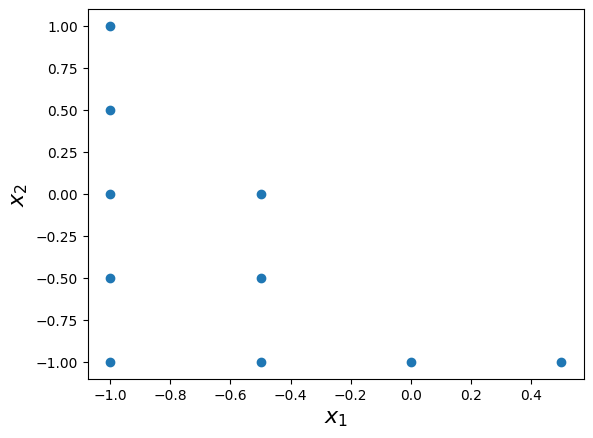

In [13]:
plt.scatter(grd.unisolvent_nodes[:, 0], grd.unisolvent_nodes[:, 1])
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$x_2$", fontsize=16);

```{note}
Regardless of the specified domain, the unisolvent nodes are stored in the internal reference domain $[-1, 1]^m$. When the domain is not $[-1, 1]^m$, Minterpy automatically transforms the nodes to the specified domain before passing them to the function, for example, when calling
`grid(func)`.
```